# Fashion-MNIST 多层感知机（MLP）训练与评估

本 Notebook 参考 `fashion_mnist_cnn` 的实现方式，使用项目目录中的 `config.py` 和 `utils.py` 来完成 Fashion-MNIST 的数据加载、训练、评估、可视化与结果保存。

## 1. 环境与依赖

导入必要库，并检查 `config` 与 `utils` 是否可用。

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping

import config
from utils import (load_fashion_mnist, plot_sample_images, plot_training_history,
                   plot_confusion_matrix, print_classification_report)

print('config.OUTPUT_DIR =', config.OUTPUT_DIR)
print('NUM_CLASSES =', config.NUM_CLASSES)
print('BATCH_SIZE =', config.BATCH_SIZE)
print('EPOCHS =', config.EPOCHS)


config.OUTPUT_DIR = /output
NUM_CLASSES = 10
BATCH_SIZE = 64
EPOCHS = 50


## 2. 数据加载与预处理

加载 Fashion-MNIST 原始 idx 数据，并将数据划分为训练、验证、测试集。

In [2]:
(train_images, train_labels), (test_images, test_labels) = load_fashion_mnist(config.DATA_DIR)
print('train_images.shape =', train_images.shape)
print('train_labels.shape =', train_labels.shape)
print('test_images.shape =', test_images.shape)
print('test_labels.shape =', test_labels.shape)

X_all = np.concatenate([train_images, test_images], axis=0)
y_all = np.concatenate([train_labels, test_labels], axis=0)

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=(1 - config.TRAIN_RATIO),
    random_state=config.RANDOM_SEED, stratify=y_all
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5,
    random_state=config.RANDOM_SEED, stratify=y_temp
)

X_train = X_train.reshape(-1, config.IMG_SIZE, config.IMG_SIZE, 1).astype('float32') / 255.0
X_val = X_val.reshape(-1, config.IMG_SIZE, config.IMG_SIZE, 1).astype('float32') / 255.0
X_test = X_test.reshape(-1, config.IMG_SIZE, config.IMG_SIZE, 1).astype('float32') / 255.0

print('X_train.shape =', X_train.shape)
print('X_val.shape =', X_val.shape)
print('X_test.shape =', X_test.shape)

train_images.shape = (60000, 28, 28)
train_labels.shape = (60000,)
test_images.shape = (10000, 28, 28)
test_labels.shape = (10000,)
X_train.shape = (48999, 28, 28, 1)
X_val.shape = (10500, 28, 28, 1)
X_test.shape = (10501, 28, 28, 1)


✅ 样本图片已保存: /output\sample_images.png


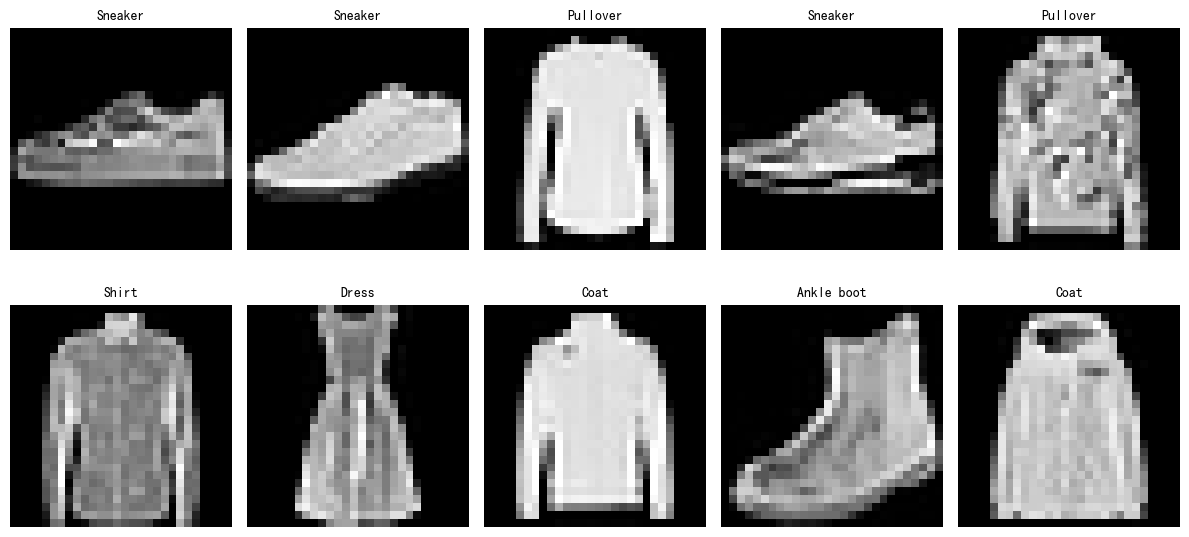

In [3]:
plot_sample_images(X_train.squeeze(), y_train, save_path=os.path.join(config.OUTPUT_DIR, 'sample_images.png'))

## 3. 模型定义

定义与 `train_mlp.py` 一致的 MLP 模型结构。

In [4]:
def create_mlp_model():
    model = Sequential([
        Input(shape=(config.IMG_SIZE, config.IMG_SIZE, 1)),
        Flatten(),
        Dense(config.MLP_HIDDEN_UNITS[0], activation='relu'),
        Dropout(config.MLP_DROPOUT_RATE),
        Dense(config.MLP_HIDDEN_UNITS[1], activation='relu'),
        Dropout(config.MLP_DROPOUT_RATE),
        Dense(config.MLP_HIDDEN_UNITS[2], activation='relu'),
        Dropout(config.MLP_DROPOUT_RATE),
        Dense(config.NUM_CLASSES, activation='softmax')
    ])
    return model

model = create_mlp_model()
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 512)               401920    
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_2 (Dense)             (None, 128)               32896     
                                                                 
 dropout_2 (Dropout)         (None, 128)               

## 4. 训练

编译并训练模型，使用早停回调避免过拟合。

In [5]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=config.PATIENCE, restore_best_weights=True, verbose=1)
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=config.EPOCHS,
    batch_size=config.BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50


766/766 [==============================] - 4s 4ms/step - loss: 0.8130 - accuracy: 0.7057 - val_loss: 0.4980 - val_accuracy: 0.8252
Epoch 2/50
766/766 [==============================] - 3s 4ms/step - loss: 0.5566 - accuracy: 0.8021 - val_loss: 0.4243 - val_accuracy: 0.8409
Epoch 3/50
766/766 [==============================] - 3s 4ms/step - loss: 0.5073 - accuracy: 0.8224 - val_loss: 0.3974 - val_accuracy: 0.8555
Epoch 4/50
766/766 [==============================] - 3s 4ms/step - loss: 0.4756 - accuracy: 0.8334 - val_loss: 0.3910 - val_accuracy: 0.8565
Epoch 5/50
766/766 [==============================] - 3s 4ms/step - loss: 0.4561 - accuracy: 0.8385 - val_loss: 0.3947 - val_accuracy: 0.8547
Epoch 6/50
766/766 [==============================] - 3s 4ms/step - loss: 0.4506 - accuracy: 0.8431 - val_loss: 0.3840 - val_accuracy: 0.8699
Epoch 7/50
766/766 [==============================] - 3s 4ms/step - loss: 0.4381 - accuracy: 0.8465 - val_loss: 0.3709 - val_accuracy: 0.8679
Epo

## 5. 评估与可视化

在测试集上评估模型性能，并保存训练曲线、混淆矩阵、分类报告和模型文件。

测试集损失: 0.3316
测试集准确率: 89.01%
329/329 [==============================] - 0s 941us/step

分类报告
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.84      0.84      1050
     Trouser       0.99      0.98      0.99      1050
    Pullover       0.81      0.84      0.82      1050
       Dress       0.89      0.92      0.90      1050
        Coat       0.78      0.84      0.81      1050
      Sandal       0.98      0.96      0.97      1050
       Shirt       0.72      0.62      0.67      1051
     Sneaker       0.95      0.96      0.96      1050
         Bag       0.97      0.97      0.97      1050
  Ankle boot       0.96      0.97      0.97      1050

    accuracy                           0.89     10501
   macro avg       0.89      0.89      0.89     10501
weighted avg       0.89      0.89      0.89     10501


各类别准确率:
----------------------------------------
T-shirt/top    : 0.8352 (83.52%)
Trouser        : 0.9810 (98.10%)
Pullover       : 0.8419 (84.19%)


/opt/anaconda3\envs\univad\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


✅ 训练曲线已保存: /output\training_history.png


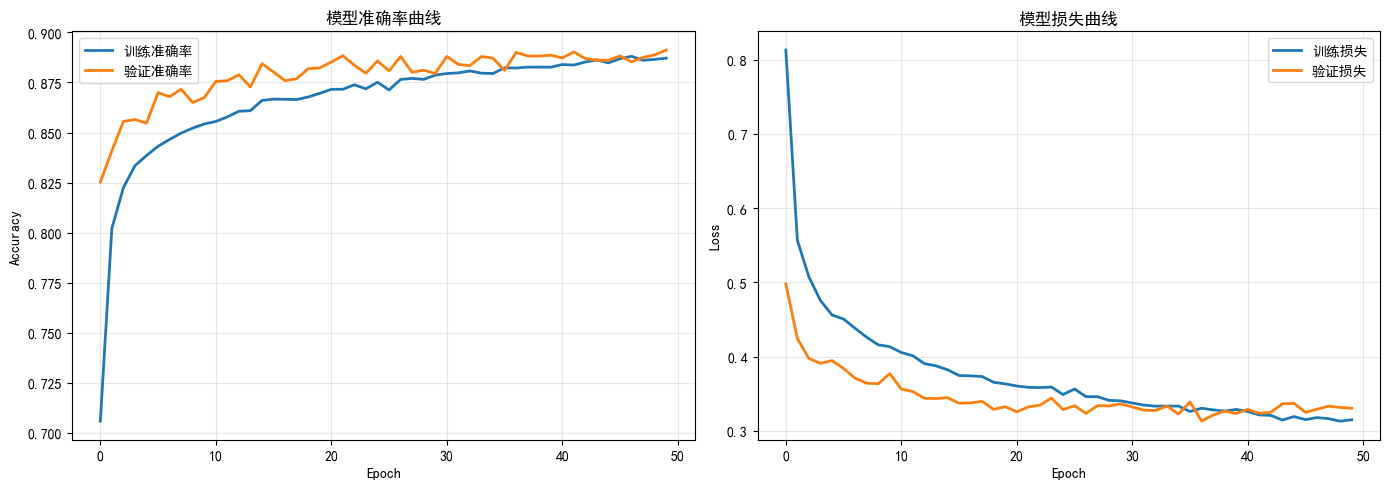

✅ 混淆矩阵已保存: /output\confusion_matrix.png


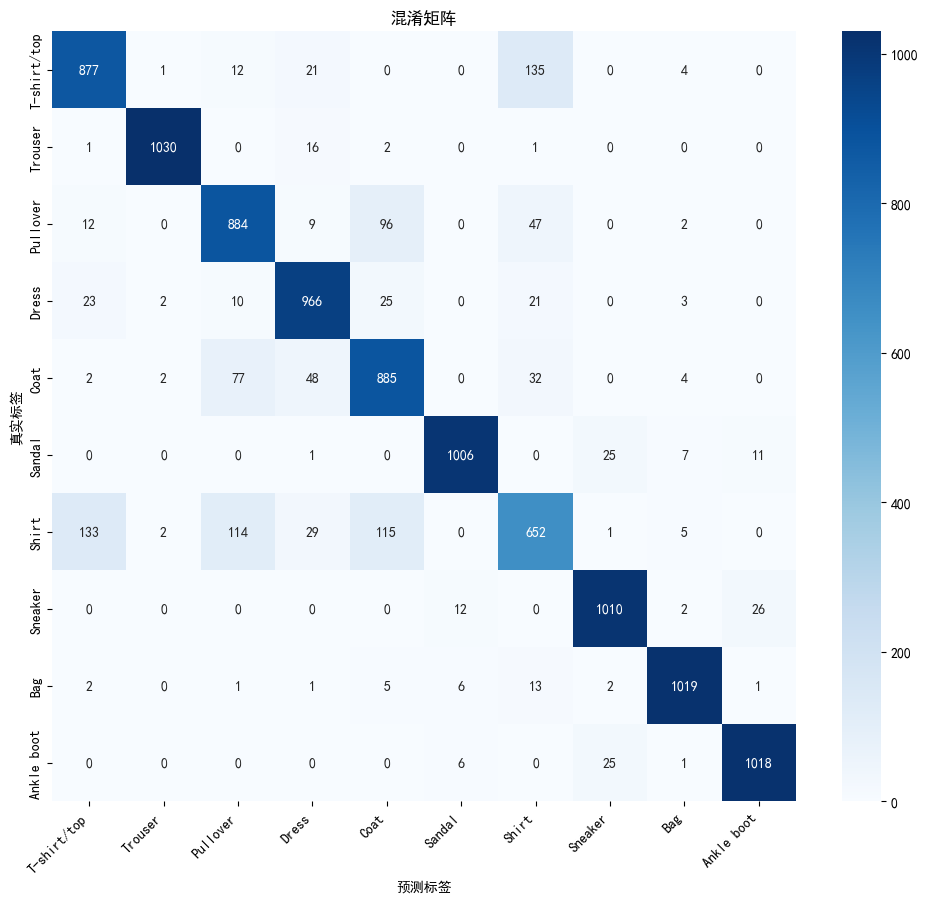

In [6]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'测试集损失: {test_loss:.4f}')
print(f'测试集准确率: {test_acc*100:.2f}%')

y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

print_classification_report(y_test, y_pred)

with open(os.path.join(config.OUTPUT_DIR, 'model_summary.txt'), 'w', encoding='utf-8') as f:
    model.summary(print_fn=lambda x: f.write(x + '\n'))

model.save(os.path.join(config.OUTPUT_DIR, 'fashion_mnist_mlp_model.h5'))
print('✅ 模型已保存到 output 文件夹')

plot_training_history(history, save_path=os.path.join(config.OUTPUT_DIR, 'training_history.png'))
plot_confusion_matrix(y_test, y_pred, save_path=os.path.join(config.OUTPUT_DIR, 'confusion_matrix.png'))

## 6. 导出为 HTML

可以使用 `jupyter nbconvert` 将本 Notebook 导出为 HTML，或在本地运行以下命令。

In [7]:
print('如果您希望手动导出 HTML：')
print('jupyter nbconvert --to html fashion_mnist_notebook.ipynb --output fashion_mnist_notebook.html')

如果您希望手动导出 HTML：
jupyter nbconvert --to html fashion_mnist_notebook.ipynb --output fashion_mnist_notebook.html
